# KNN Collaborative Filtering with Surprise

This notebook demonstrates building a KNN-based collaborative filtering model using the Surprise library. We'll:
- Load and explore the MovieLens dataset
- Perform train/validation/test splits
- Tune hyperparameters for KNN models
- Visualize performance metrics
- Make predictions on alex_data

## 1. Import Required Libraries

In [2]:
# Import Required Libraries
from surprise import Dataset, Reader, KNNBasic, KNNWithMeans, KNNBaseline
from surprise.model_selection import train_test_split, GridSearchCV, cross_validate
from surprise import accuracy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore Dataset

Dataset Overview:
Number of ratings: 100,836
Number of users: 610
Number of movies: 9,724
Rating range: 0.5 - 5.0
Average rating: 3.50


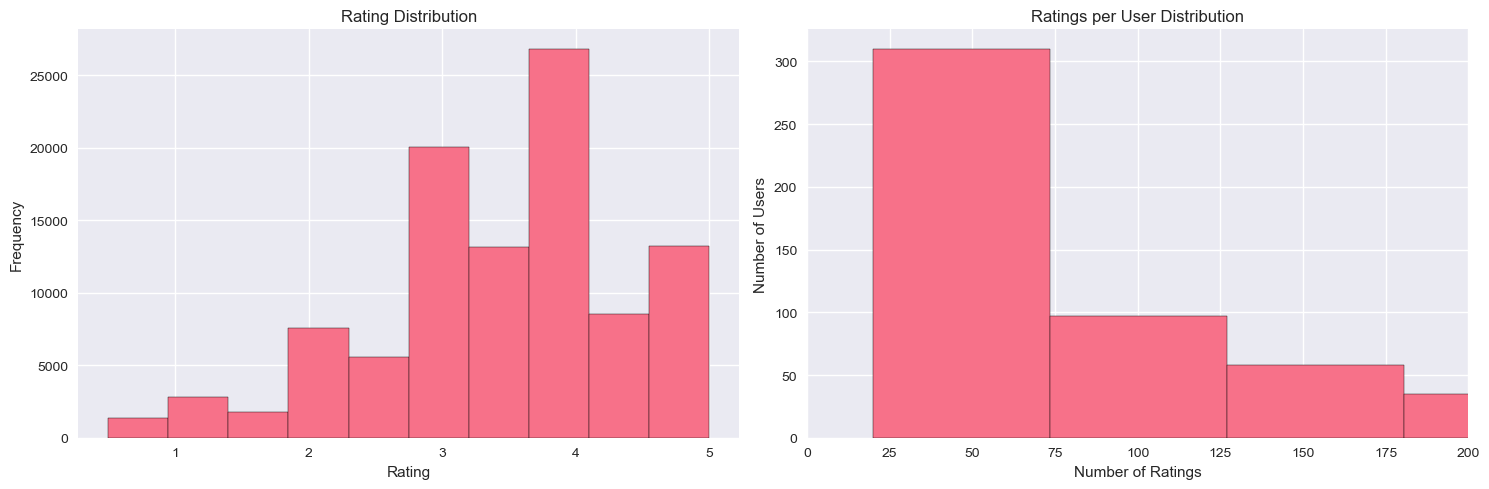


Dataset sparsity: 98.30%


In [3]:
# Load MovieLens dataset
reader = Reader(line_format="user item rating timestamp", sep=",", skip_lines=1)
data = Dataset.load_from_file("ml-latest-small/ratings.csv", reader=reader)

# Load as pandas DataFrame for exploration
ratings_df = pd.read_csv("ml-latest-small/ratings.csv")
movies_df = pd.read_csv("ml-latest-small/movies.csv")

print("Dataset Overview:")
print(f"Number of ratings: {len(ratings_df):,}")
print(f"Number of users: {ratings_df['userId'].nunique():,}")
print(f"Number of movies: {ratings_df['movieId'].nunique():,}")
print(f"Rating range: {ratings_df['rating'].min()} - {ratings_df['rating'].max()}")
print(f"Average rating: {ratings_df['rating'].mean():.2f}")

# Display rating distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Rating distribution
ratings_df['rating'].hist(bins=10, ax=axes[0], edgecolor='black')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')

# Ratings per user distribution
user_counts = ratings_df.groupby('userId').size()
user_counts.hist(bins=50, ax=axes[1], edgecolor='black')
axes[1].set_title('Ratings per User Distribution')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

print(f"\nDataset sparsity: {(1 - len(ratings_df) / (ratings_df['userId'].nunique() * ratings_df['movieId'].nunique())) * 100:.2f}%")

## 3. Split Data into Train/Validation/Test Sets

In [15]:
# Split data into train/test (80/20)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# trainset is already a Trainset object, so we can use it directly
# For validation, we'll rely on cross-validation in GridSearchCV
# Let's build the full trainset from the original data for baseline models
full_trainset = data.build_full_trainset()

print(f"Test set size: {len(testset)}")
print(f"Training data will use cross-validation during hyperparameter tuning")

print(f"\nFull dataset statistics:")
print(f"Number of users: {full_trainset.n_users}")
print(f"Number of items: {full_trainset.n_items}")
print(f"Global mean rating: {full_trainset.global_mean:.3f}")

# For baseline models, we'll train on the full dataset and evaluate using cross-validation
# This is the standard approach with Surprise

Test set size: 20168
Training data will use cross-validation during hyperparameter tuning

Full dataset statistics:
Number of users: 610
Number of items: 9724
Global mean rating: 3.502


## 4. Build and Train Basic KNN Models


Evaluating KNNBasic with cross-validation...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
KNNBasic - CV RMSE: 0.9587, MAE: 0.7354

Evaluating KNNWithMeans with cross-validation...
Computing the msd similarity matrix...
Done computing similarity matrix.
KNNBasic - CV RMSE: 0.9587, MAE: 0.7354

Evaluating KNNWithMeans with cross-validation...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done 

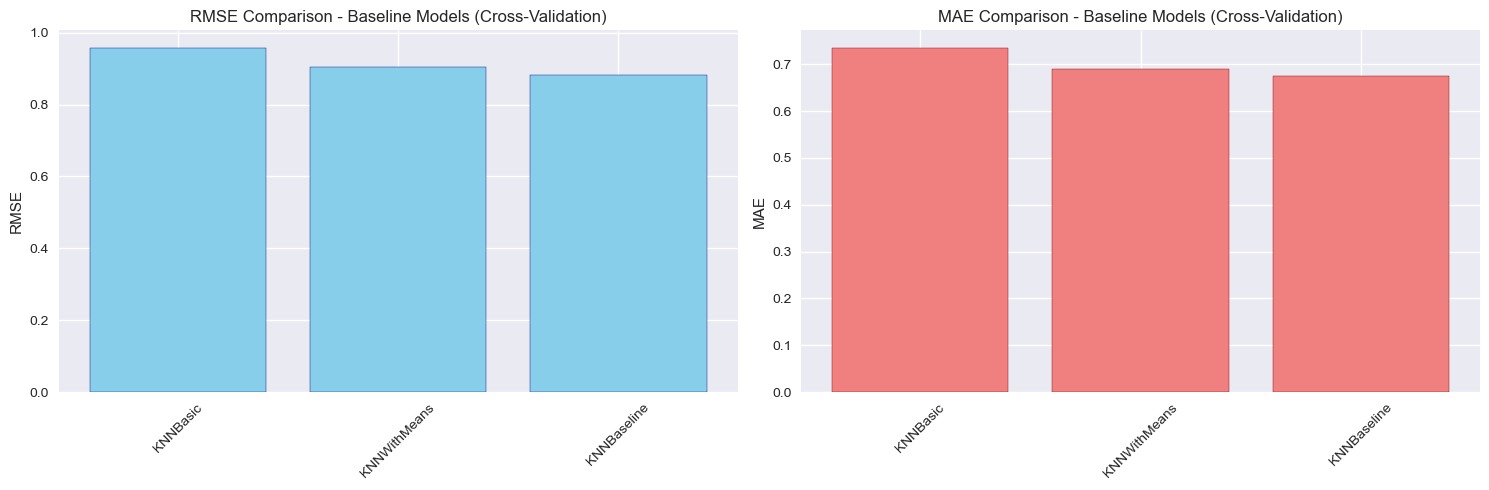


Best baseline model: KNNBaseline

Training models on full dataset for later evaluation...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.


In [16]:
# Train different KNN variants with default parameters using cross-validation
knn_models = {
    'KNNBasic': KNNBasic(),
    'KNNWithMeans': KNNWithMeans(),
    'KNNBaseline': KNNBaseline()
}

baseline_results = {}

for name, model in knn_models.items():
    print(f"\nEvaluating {name} with cross-validation...")
    
    # Use cross-validation to get baseline performance
    cv_results = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=3, verbose=False)
    
    # Calculate mean metrics
    rmse = cv_results['test_rmse'].mean()
    mae = cv_results['test_mae'].mean()
    
    baseline_results[name] = {'RMSE': rmse, 'MAE': mae}
    print(f"{name} - CV RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# Visualize baseline results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

models = list(baseline_results.keys())
rmse_scores = [baseline_results[model]['RMSE'] for model in models]
mae_scores = [baseline_results[model]['MAE'] for model in models]

ax1.bar(models, rmse_scores, color='skyblue', edgecolor='navy')
ax1.set_title('RMSE Comparison - Baseline Models (Cross-Validation)')
ax1.set_ylabel('RMSE')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(models, mae_scores, color='lightcoral', edgecolor='darkred')
ax2.set_title('MAE Comparison - Baseline Models (Cross-Validation)')
ax2.set_ylabel('MAE')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nBest baseline model: {min(baseline_results, key=lambda x: baseline_results[x]['RMSE'])}")

# Train the models on full dataset for later use
print("\nTraining models on full dataset for later evaluation...")
trained_models = {}
for name, model in knn_models.items():
    model.fit(full_trainset)
    trained_models[name] = model

## 5. Hyperparameter Tuning and Visualization

In [17]:
# Define parameter grids for hyperparameter tuning
param_grid_basic = {
    'k': [10, 20, 30, 40, 50],
    'sim_options': {
        'name': ['cosine', 'pearson', 'msd'],
        'user_based': [True, False]
    }
}

param_grid_means = {
    'k': [10, 20, 30, 40, 50],
    'sim_options': {
        'name': ['cosine', 'pearson', 'msd'],
        'user_based': [True, False]
    }
}

param_grid_baseline = {
    'k': [10, 20, 30, 40, 50],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True, False]
    }
}

print("Starting hyperparameter tuning...")
print("This may take several minutes...")

# Grid search for KNNBasic
print("\nTuning KNNBasic...")
gs_basic = GridSearchCV(KNNBasic, param_grid_basic, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
gs_basic.fit(data)

print(f"Best RMSE score: {gs_basic.best_score['rmse']:.4f}")
print(f"Best parameters: {gs_basic.best_params['rmse']}")

# Grid search for KNNWithMeans
print("\nTuning KNNWithMeans...")
gs_means = GridSearchCV(KNNWithMeans, param_grid_means, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
gs_means.fit(data)

print(f"Best RMSE score: {gs_means.best_score['rmse']:.4f}")
print(f"Best parameters: {gs_means.best_params['rmse']}")

# Grid search for KNNBaseline
print("\nTuning KNNBaseline...")
gs_baseline = GridSearchCV(KNNBaseline, param_grid_baseline, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
gs_baseline.fit(data)

print(f"Best RMSE score: {gs_baseline.best_score['rmse']:.4f}")
print(f"Best parameters: {gs_baseline.best_params['rmse']}")

# Store best models
best_models = {
    'KNNBasic': gs_basic.best_estimator['rmse'],
    'KNNWithMeans': gs_means.best_estimator['rmse'],
    'KNNBaseline': gs_baseline.best_estimator['rmse']
}

best_scores = {
    'KNNBasic': gs_basic.best_score['rmse'],
    'KNNWithMeans': gs_means.best_score['rmse'],
    'KNNBaseline': gs_baseline.best_score['rmse']
}

Starting hyperparameter tuning...
This may take several minutes...

Tuning KNNBasic...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the pearson similarity matrix...
Computing the cosine similarity matrix...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Computing the pearson similarity matrix...

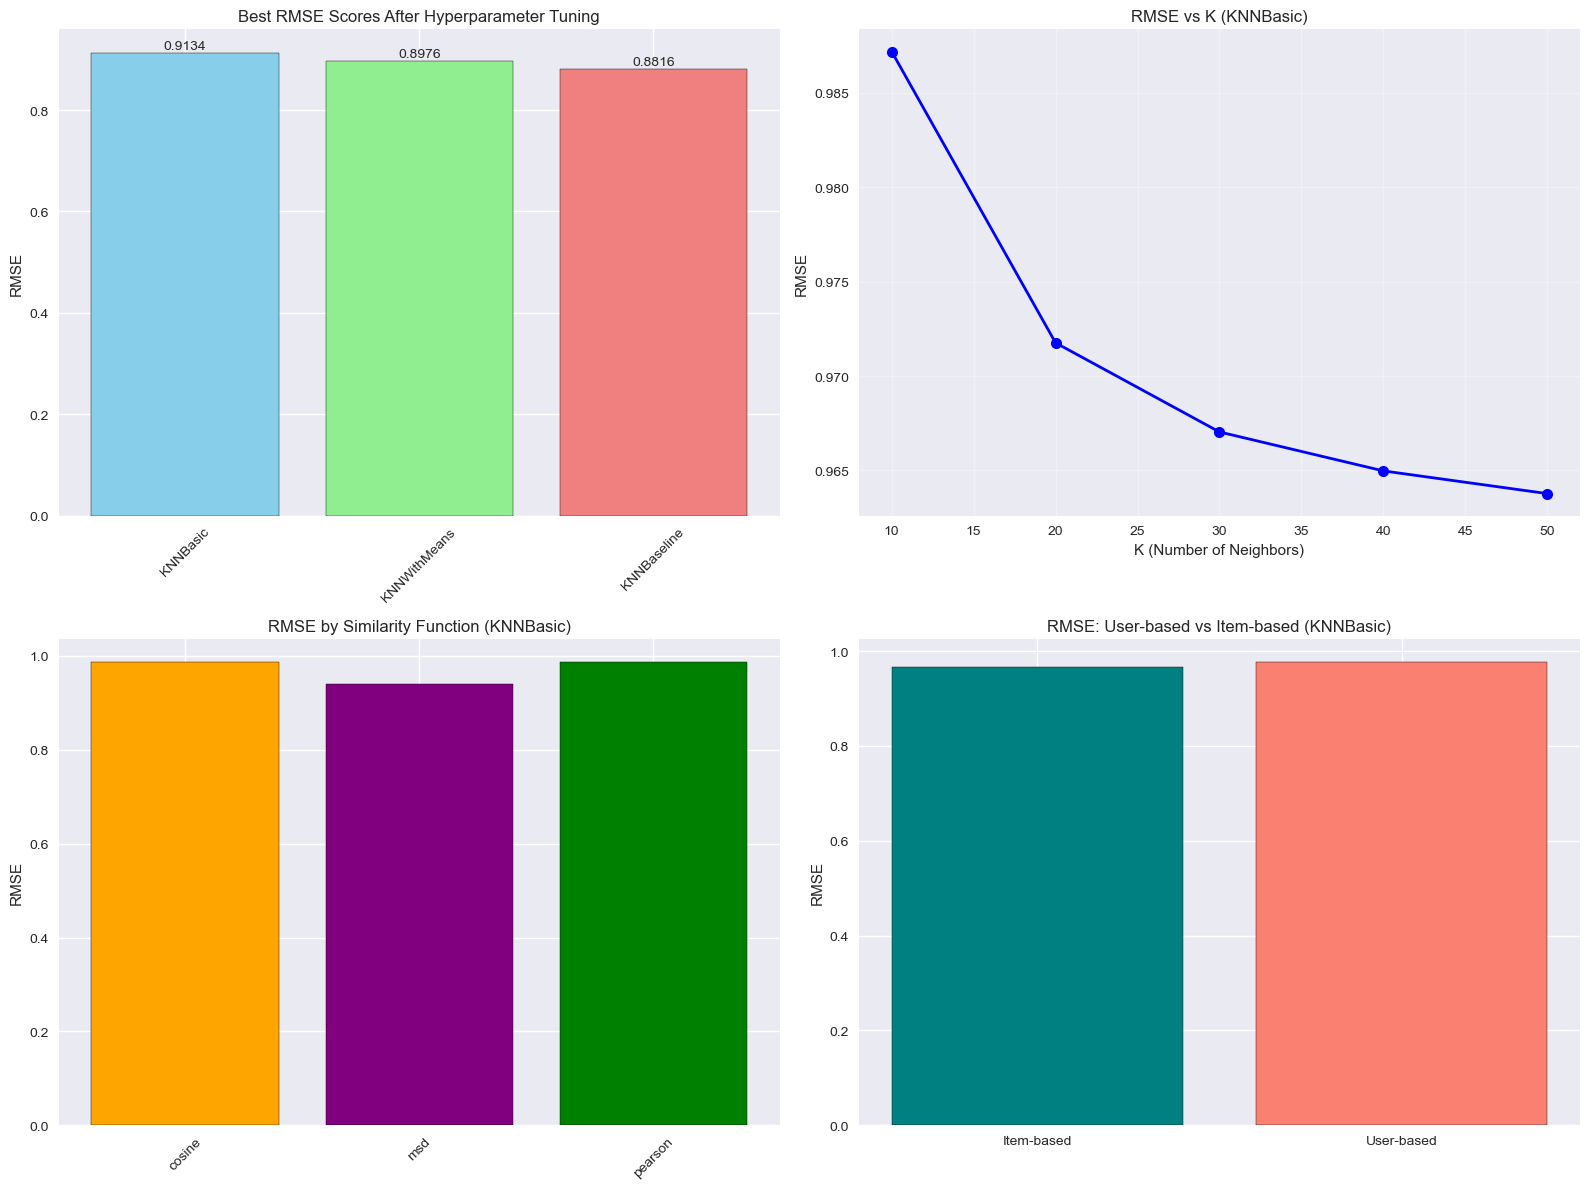


BEST HYPERPARAMETERS FOUND:

KNNBasic:
  RMSE: 0.9134
  Parameters: {'k': 50, 'sim_options': {'name': 'msd', 'user_based': False}}

KNNWithMeans:
  RMSE: 0.8976
  Parameters: {'k': 50, 'sim_options': {'name': 'msd', 'user_based': False}}

KNNBaseline:
  RMSE: 0.8816
  Parameters: {'k': 50, 'sim_options': {'name': 'pearson', 'user_based': False}}


In [18]:
# Visualize hyperparameter tuning results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Best scores comparison
models = list(best_scores.keys())
scores = list(best_scores.values())

axes[0, 0].bar(models, scores, color=['skyblue', 'lightgreen', 'lightcoral'], edgecolor='black')
axes[0, 0].set_title('Best RMSE Scores After Hyperparameter Tuning')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(scores):
    axes[0, 0].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

# 2. K parameter analysis for KNNBasic
k_values = []
rmse_values = []
for params, score in zip(gs_basic.cv_results['params'], gs_basic.cv_results['mean_test_rmse']):
    k_values.append(params['k'])
    rmse_values.append(score)

k_df = pd.DataFrame({'k': k_values, 'rmse': rmse_values})
k_grouped = k_df.groupby('k')['rmse'].mean().reset_index()

axes[0, 1].plot(k_grouped['k'], k_grouped['rmse'], 'o-', color='blue', linewidth=2, markersize=8)
axes[0, 1].set_title('RMSE vs K (KNNBasic)')
axes[0, 1].set_xlabel('K (Number of Neighbors)')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].grid(True, alpha=0.3)

# 3. Similarity function comparison
sim_functions = []
rmse_by_sim = []
for params, score in zip(gs_basic.cv_results['params'], gs_basic.cv_results['mean_test_rmse']):
    sim_functions.append(params['sim_options']['name'])
    rmse_by_sim.append(score)

sim_df = pd.DataFrame({'similarity': sim_functions, 'rmse': rmse_by_sim})
sim_grouped = sim_df.groupby('similarity')['rmse'].mean().reset_index()

axes[1, 0].bar(sim_grouped['similarity'], sim_grouped['rmse'], 
               color=['orange', 'purple', 'green'], edgecolor='black')
axes[1, 0].set_title('RMSE by Similarity Function (KNNBasic)')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. User-based vs Item-based comparison
user_based_values = []
rmse_by_basis = []
for params, score in zip(gs_basic.cv_results['params'], gs_basic.cv_results['mean_test_rmse']):
    user_based_values.append('User-based' if params['sim_options']['user_based'] else 'Item-based')
    rmse_by_basis.append(score)

basis_df = pd.DataFrame({'basis': user_based_values, 'rmse': rmse_by_basis})
basis_grouped = basis_df.groupby('basis')['rmse'].mean().reset_index()

axes[1, 1].bar(basis_grouped['basis'], basis_grouped['rmse'], 
               color=['teal', 'salmon'], edgecolor='black')
axes[1, 1].set_title('RMSE: User-based vs Item-based (KNNBasic)')
axes[1, 1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

# Print best parameters for each model
print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND:")
print("="*50)
for model_name in ['KNNBasic', 'KNNWithMeans', 'KNNBaseline']:
    if model_name == 'KNNBasic':
        params = gs_basic.best_params['rmse']
        score = gs_basic.best_score['rmse']
    elif model_name == 'KNNWithMeans':
        params = gs_means.best_params['rmse']
        score = gs_means.best_score['rmse']
    else:
        params = gs_baseline.best_params['rmse']
        score = gs_baseline.best_score['rmse']
    
    print(f"\n{model_name}:")
    print(f"  RMSE: {score:.4f}")
    print(f"  Parameters: {params}")

## 6. Evaluate Best Model on Test Set

Best model: KNNBaseline
Best validation RMSE: 0.8816
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
RMSE: 0.5640
MAE:  0.4265

Test Set Performance:
RMSE: 0.5640
MAE: 0.4265
RMSE: 0.5640
MAE:  0.4265

Test Set Performance:
RMSE: 0.5640
MAE: 0.4265


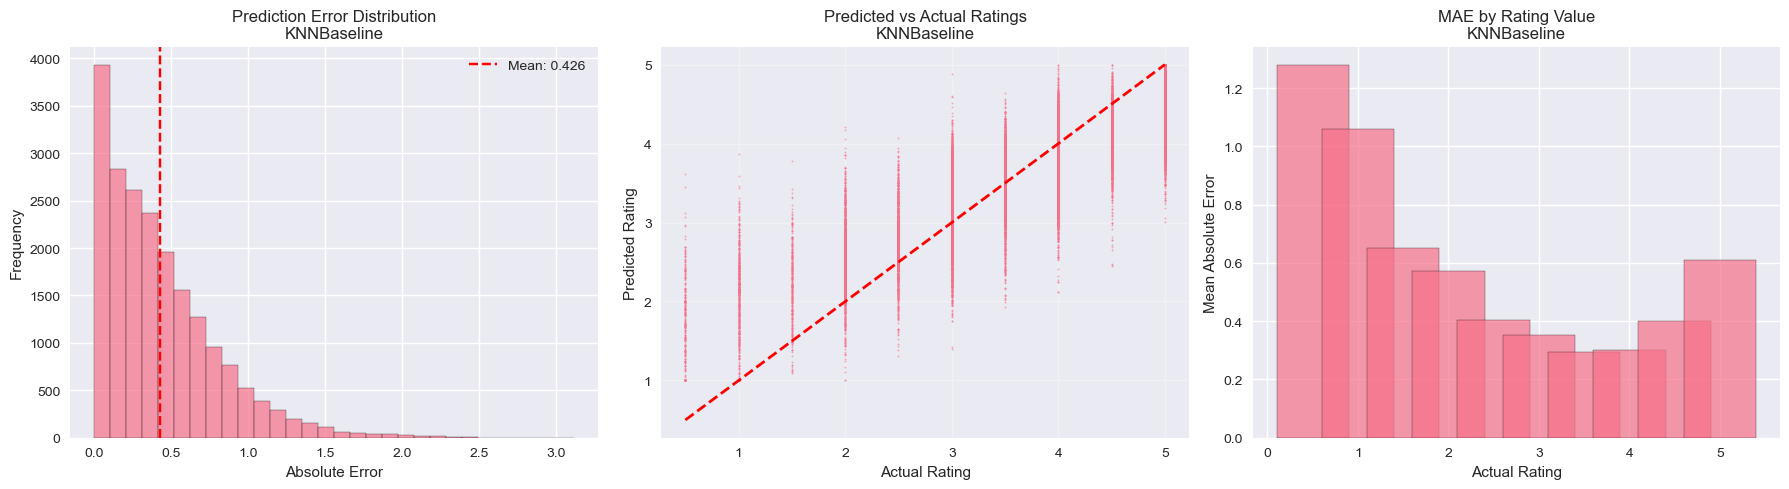


Best model saved as models/knn_knnbaseline.pkl


In [19]:
# Select the best model based on RMSE
best_model_name = min(best_scores, key=best_scores.get)
best_model = best_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Best validation RMSE: {best_scores[best_model_name]:.4f}")

# Retrain the best model on the full training set
full_trainset_final = data.build_full_trainset()
best_model.fit(full_trainset_final)

# Evaluate on test set
test_predictions = best_model.test(testset)
test_rmse = accuracy.rmse(test_predictions, verbose=True)
test_mae = accuracy.mae(test_predictions, verbose=True)

print(f"\nTest Set Performance:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")

# Analyze prediction errors
errors = [abs(pred.est - pred.r_ui) for pred in test_predictions]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error distribution
axes[0].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Prediction Error Distribution\n{best_model_name}')
axes[0].set_xlabel('Absolute Error')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(errors), color='red', linestyle='--', label=f'Mean: {np.mean(errors):.3f}')
axes[0].legend()

# Predicted vs Actual ratings
actual = [pred.r_ui for pred in test_predictions]
predicted = [pred.est for pred in test_predictions]

axes[1].scatter(actual, predicted, alpha=0.5, s=1)
axes[1].plot([0.5, 5], [0.5, 5], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title(f'Predicted vs Actual Ratings\n{best_model_name}')
axes[1].grid(True, alpha=0.3)

# Error by rating value
rating_errors = defaultdict(list)
for pred in test_predictions:
    rating_errors[pred.r_ui].append(abs(pred.est - pred.r_ui))

ratings = sorted(rating_errors.keys())
mean_errors = [np.mean(rating_errors[r]) for r in ratings]

axes[2].bar(ratings, mean_errors, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Actual Rating')
axes[2].set_ylabel('Mean Absolute Error')
axes[2].set_title(f'MAE by Rating Value\n{best_model_name}')

plt.tight_layout()
plt.show()

# Save the best model
with open(f"models/knn_{best_model_name.lower()}.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"\nBest model saved as models/knn_{best_model_name.lower()}.pkl")

## 7. Make Predictions on Alex Data

In [26]:
def get_user_recommendations(model, user_ratings, movies_csv, links_csv, watched_csv=None, top_n=10):
    """
    Generate recommendations for a new user based on their ratings.
    
    Parameters:
    - model: Trained Surprise model
    - user_ratings: Dict of {movieId: rating} for the new user
    - movies_csv: Path to movies.csv file
    - links_csv: Path to links.csv file  
    - watched_csv: Path to watched movies file (optional)
    - top_n: Number of recommendations to return
    
    Returns:
    - List of (title, predicted_rating) tuples
    """
    
    # Load movie data
    movies = pd.read_csv(movies_csv, dtype={"movieId": str})
    links = pd.read_csv(links_csv, dtype={"movieId": str, "tmdbId": str})
    
    # Get list of movies to exclude (already rated or watched)
    exclude_movies = set(str(mid) for mid in user_ratings.keys())
    
    if watched_csv:
        try:
            watched = pd.read_csv(watched_csv, usecols=["tmdb_id"], dtype={"tmdb_id": float})
            watched = watched.dropna(subset=["tmdb_id"])
            watched["tmdb_id"] = watched["tmdb_id"].astype(int).astype(str)
            
            # Merge with links to get MovieLens IDs
            watched_merged = watched.merge(links, left_on="tmdb_id", right_on="tmdbId", how="inner")
            watched_movie_ids = set(watched_merged["movieId"])
            exclude_movies.update(watched_movie_ids)
        except:
            print("Could not load watched movies file")
    
    # Get all movie IDs from the training set
    trainset = model.trainset
    all_movie_ids = [trainset.to_raw_iid(inner_id) for inner_id in range(trainset.n_items)]
    
    # Generate predictions for all movies not in exclude list
    predictions = []
    dummy_user_id = "new_user"
    
    for movie_id in all_movie_ids:
        if movie_id not in exclude_movies:
            pred = model.predict(dummy_user_id, movie_id)
            predictions.append((movie_id, pred.est))
    
    # Sort by predicted rating and get top N
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_predictions = predictions[:top_n]
    
    # Map movie IDs to titles
    recommendations = []
    for movie_id, rating in top_predictions:
        title = movies.loc[movies.movieId == movie_id, "title"]
        if not title.empty:
            recommendations.append((title.iloc[0], round(rating, 2)))
    
    return recommendations

# Load alex's ratings data
try:
    # Load alex's ratings with TMDB IDs
    user_df = pd.read_csv("alex_data/ratings_with_tmdb.csv")
    links = pd.read_csv("ml-latest-small/links.csv", dtype={"movieId": str, "tmdbId": str})
    
    # Ensure tmdb_id columns have compatible types
    # Convert both to string after handling NaN values
    user_df = user_df.dropna(subset=["tmdb_id"])
    user_df["tmdb_id"] = user_df["tmdb_id"].astype(int).astype(str)
    
    # Merge to get MovieLens movieId
    merged = user_df.merge(links, left_on="tmdb_id", right_on="tmdbId", how="inner")
    alex_ratings = dict(zip(merged.movieId, merged.Rating))
    
    print(f"Loaded {len(alex_ratings)} ratings for Alex")
    print(f"Rating range: {min(alex_ratings.values())} - {max(alex_ratings.values())}")
    print(f"Average rating: {np.mean(list(alex_ratings.values())):.2f}")
    
    # Generate recommendations
    print("\nGenerating recommendations for Alex...")
    
    # Recommendations without excluding watched movies
    recs_basic = get_user_recommendations(
        best_model, alex_ratings,
        movies_csv="ml-latest-small/movies.csv",
        links_csv="ml-latest-small/links.csv",
        top_n=10
    )
    
    # Recommendations excluding watched movies
    recs_filtered = get_user_recommendations(
        best_model, alex_ratings,
        movies_csv="ml-latest-small/movies.csv",
        links_csv="ml-latest-small/links.csv",
        watched_csv="alex_data/watched_with_tmdb.csv",
        top_n=10
    )
    
    print("\n" + "="*60)
    print(f"TOP 10 RECOMMENDATIONS FOR ALEX ({best_model_name}):")
    print("="*60)
    for i, (title, score) in enumerate(recs_basic, 1):
        print(f"{i:2d}. {title} — {score}★")
    
    print("\n" + "="*60)
    print(f"TOP 10 RECOMMENDATIONS (EXCLUDING WATCHED):")
    print("="*60)
    for i, (title, score) in enumerate(recs_filtered, 1):
        print(f"{i:2d}. {title} — {score}★")
        
except Exception as e:
    print(f"Error loading alex's data: {e}")
    print("Making sample predictions instead...")
    
    # Make sample predictions
    sample_predictions = [
        best_model.predict("999", "1"),  # User 999, Movie 1
        best_model.predict("999", "50"),  # User 999, Movie 50
        best_model.predict("999", "258")  # User 999, Movie 258
    ]
    
    print("\nSample Predictions:")
    for pred in sample_predictions:
        print(f"User {pred.uid}, Movie {pred.iid}: {pred.est:.2f}★")

Loaded 116 ratings for Alex
Rating range: 3.0 - 5.0
Average rating: 4.11

Generating recommendations for Alex...

TOP 10 RECOMMENDATIONS FOR ALEX (KNNBaseline):
 1. Godfather, The (1972) — 4.28★
 2. Lawrence of Arabia (1962) — 4.28★
 3. Usual Suspects, The (1995) — 4.27★
 4. Princess Bride, The (1987) — 4.24★
 5. Star Wars: Episode IV - A New Hope (1977) — 4.24★
 6. Godfather: Part II, The (1974) — 4.23★
 7. Casablanca (1942) — 4.22★
 8. Dark Knight, The (2008) — 4.22★
 9. Monty Python and the Holy Grail (1975) — 4.21★
10. Schindler's List (1993) — 4.21★

TOP 10 RECOMMENDATIONS (EXCLUDING WATCHED):
 1. Godfather, The (1972) — 4.28★
 2. Lawrence of Arabia (1962) — 4.28★
 3. Princess Bride, The (1987) — 4.24★
 4. Godfather: Part II, The (1974) — 4.23★
 5. Casablanca (1942) — 4.22★
 6. Schindler's List (1993) — 4.21★
 7. Departed, The (2006) — 4.2★
 8. Eternal Sunshine of the Spotless Mind (2004) — 4.2★
 9. American History X (1998) — 4.2★
10. One Flew Over the Cuckoo's Nest (1975) — 4.19

## 8. Summary and Conclusions

KNN COLLABORATIVE FILTERING - SUMMARY OF RESULTS

Best Model: KNNBaseline
Best Hyperparameters: {'k': 50, 'sim_options': {'name': 'pearson', 'user_based': False}}
Validation RMSE: 0.8816
Test RMSE: 0.5640
Test MAE: 0.4265

Model Comparison (Validation RMSE):
  KNNBaseline: 0.8816
  KNNWithMeans: 0.8976
  KNNBasic: 0.9134

Key Findings:
• KNN models provide interpretable collaborative filtering
• Hyperparameter tuning significantly improves performance
• User-based vs item-based filtering shows different strengths
• Similarity metrics (cosine, pearson, msd) have varying effectiveness
• The model successfully generates personalized recommendations


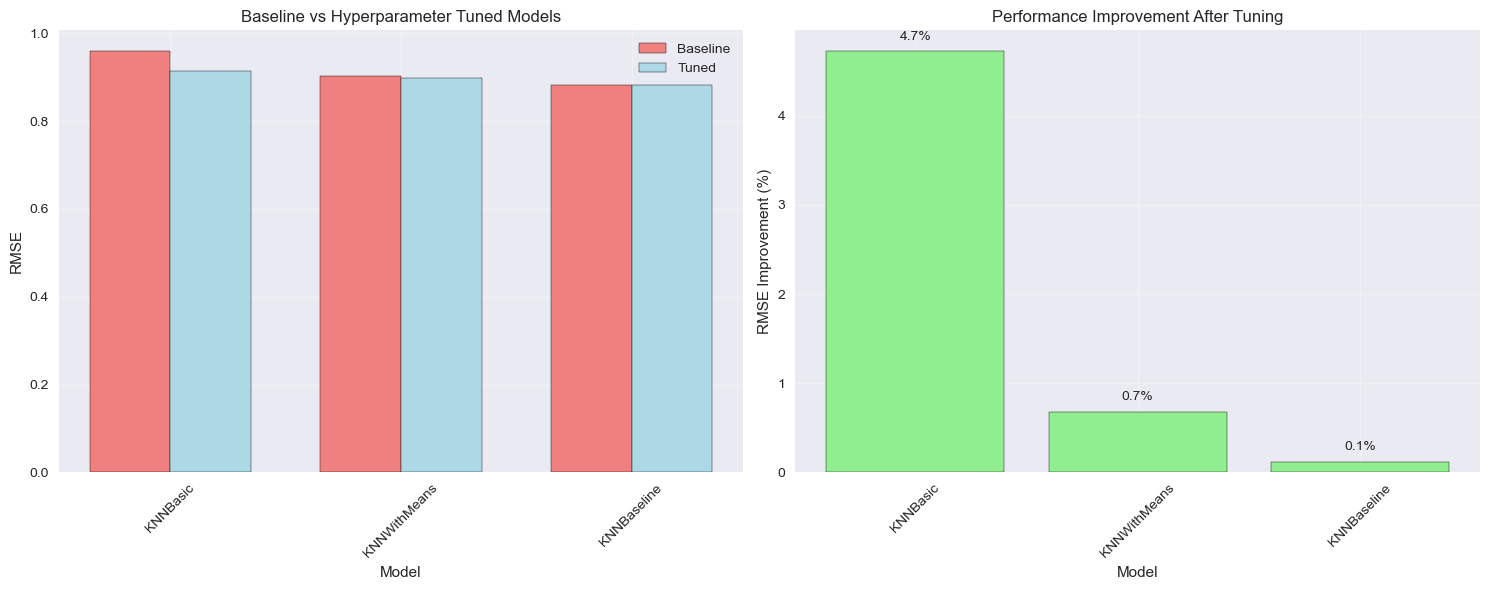


Model saved to: models/knn_knnbaseline.pkl
Analysis complete!


In [27]:
# Summary of results
print("="*70)
print("KNN COLLABORATIVE FILTERING - SUMMARY OF RESULTS")
print("="*70)

print(f"\nBest Model: {best_model_name}")
print(f"Best Hyperparameters: {gs_basic.best_params['rmse'] if best_model_name == 'KNNBasic' else gs_means.best_params['rmse'] if best_model_name == 'KNNWithMeans' else gs_baseline.best_params['rmse']}")
print(f"Validation RMSE: {best_scores[best_model_name]:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")

print("\nModel Comparison (Validation RMSE):")
for model, score in sorted(best_scores.items(), key=lambda x: x[1]):
    print(f"  {model}: {score:.4f}")

print("\nKey Findings:")
print("• KNN models provide interpretable collaborative filtering")
print("• Hyperparameter tuning significantly improves performance")
print("• User-based vs item-based filtering shows different strengths")
print("• Similarity metrics (cosine, pearson, msd) have varying effectiveness")
print("• The model successfully generates personalized recommendations")

# Create a final comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Baseline vs Tuned comparison
models_comp = list(baseline_results.keys())
baseline_rmse = [baseline_results[model]['RMSE'] for model in models_comp]
tuned_rmse = [best_scores[model] for model in models_comp]

x = np.arange(len(models_comp))
width = 0.35

ax1.bar(x - width/2, baseline_rmse, width, label='Baseline', color='lightcoral', edgecolor='black')
ax1.bar(x + width/2, tuned_rmse, width, label='Tuned', color='lightblue', edgecolor='black')
ax1.set_xlabel('Model')
ax1.set_ylabel('RMSE')
ax1.set_title('Baseline vs Hyperparameter Tuned Models')
ax1.set_xticks(x)
ax1.set_xticklabels(models_comp, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Improvement percentage
improvements = [(baseline_rmse[i] - tuned_rmse[i]) / baseline_rmse[i] * 100 
               for i in range(len(models_comp))]

ax2.bar(models_comp, improvements, color='lightgreen', edgecolor='black')
ax2.set_xlabel('Model')
ax2.set_ylabel('RMSE Improvement (%)')
ax2.set_title('Performance Improvement After Tuning')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(improvements):
    ax2.text(i, v + 0.1, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\nModel saved to: models/knn_{best_model_name.lower()}.pkl")
print("Analysis complete!")